# BrandRadar — Estimated Attention Map Notebook

Este cuaderno prototipa un módulo de **Estimated Attention Map** para BrandRadar.

## Objetivo

No queremos detectar objetos. Queremos estimar **focos probables de atención visual** dentro de una pieza.

El modelo es heurístico y explicable. Sirve para explorar antes de llevarlo al backend.

## Señales usadas

Cada celda del asset recibe un score basado en:

1. Local Contrast
2. Relative Visual Activity / Size
3. Centrality
4. Edge Density
5. Saturation Difference
6. OCR / Text Priority
7. Isolation

## Outputs esperados

- Heatmap estimado
- Overlay sobre imagen
- Top attention zones
- Focus Clarity
- Attention Dispersion
- Lectura textual

In [ ]:
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps, ImageStat, ImageFilter, ImageDraw
from google.colab import files

!apt-get update -qq
!apt-get install -y tesseract-ocr tesseract-ocr-spa
!pip install pytesseract

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  tesseract-ocr-spa
0 upgraded, 1 newly installed, 0 to remove and 8 not upgraded.
Need to get 951 kB of archives.
After this operation, 2,309 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-spa all 1:4.00~git30-7274cfa-1.1 [951 kB]
Fetched 951 kB in 0s (9,175 kB/s)
Selecting previously unselected package tesseract-ocr-spa.
(Reading database ... 118212 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-spa_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-spa (1:4.00~git30-7274cfa-1.1) ..

## 1. Upload del asset

Saving BF-AN_03-10.jpg to BF-AN_03-10.jpg
Loaded: BF-AN_03-10.jpg
Size: (1080, 1920)


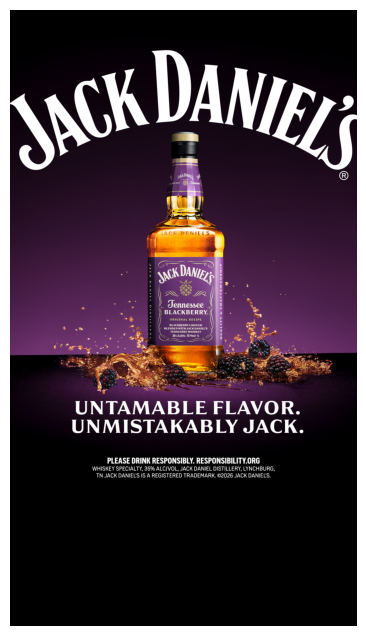

In [ ]:
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

print("Loaded:", image_path)
print("Size:", image.size)

plt.figure(figsize=(6, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

## 2. Helpers

In [ ]:
def clamp01(value):
    return max(0.0, min(1.0, float(value)))

def normalize_array(arr):
    arr = np.asarray(arr, dtype=float)
    min_v = np.nanmin(arr)
    max_v = np.nanmax(arr)
    if max_v - min_v < 1e-9:
        return np.zeros_like(arr)
    return (arr - min_v) / (max_v - min_v)

def gaussian_like_blur_grid(grid, passes=2):
    # Blur simple sin SciPy: promedio de vecinos
    grid = grid.astype(float)
    for _ in range(passes):
        padded = np.pad(grid, 1, mode="edge")
        out = np.zeros_like(grid)
        for y in range(grid.shape[0]):
            for x in range(grid.shape[1]):
                region = padded[y:y+3, x:x+3]
                kernel = np.array([
                    [1, 2, 1],
                    [2, 4, 2],
                    [1, 2, 1]
                ], dtype=float)
                out[y, x] = np.sum(region * kernel) / kernel.sum()
        grid = out
    return grid

def show_image(img, title=None, figsize=(7, 9)):
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

## 3. OCR opcional

In [ ]:
def try_ocr_text(img):
    try:
        import pytesseract
        text = pytesseract.image_to_string(img, lang="eng+spa")
        return text or ""
    except Exception as e:
        print("OCR unavailable. Continuing without OCR.")
        print("Reason:", e)
        return ""

ocr_text = try_ocr_text(image)

print("OCR text preview:")
print(ocr_text[:1200] if ocr_text.strip() else "[No OCR text detected]")

priority_patterns = [
    r"sale", r"off", r"discount", r"promo", r"offer", r"deal",
    r"buy", r"shop", r"now", r"limited", r"save", r"free",
    r"precio", r"oferta", r"descuento", r"compra", r"ahora",
    r"%", r"$", r"\d+x", r"\d+%"
]

def text_priority_score(text):
    clean = text.strip()
    if not clean:
        return 0.0

    words = re.findall(r"\\b\\w+\\b", clean)
    numbers = re.findall(r"\\d+", clean)
    promo_hits = sum(
        len(re.findall(pattern, clean, flags=re.IGNORECASE))
        for pattern in priority_patterns
    )
    uppercase_words = [w for w in words if len(w) > 2 and w.isupper()]

    word_pressure = clamp01(len(words) / 100)
    number_pressure = clamp01(len(numbers) / 20)
    promo_pressure = clamp01(promo_hits / 10)
    uppercase_pressure = 0 if not words else clamp01((len(uppercase_words) / len(words)) * 2)

    return clamp01(
        0.35 * promo_pressure +
        0.25 * number_pressure +
        0.20 * uppercase_pressure +
        0.20 * word_pressure
    )

global_text_priority = text_priority_score(ocr_text)
global_text_priority

OCR text preview:
    

UNTAMABLE FLAVOR.
UNMISTAKABLY JACK.

PLEASE DRINK RESPONSIBLY. RESPONSIBILITY.ORG
WHISKEY SPECIALTY, 35% ALCIVOL, JACK DANIEL DISTILLERY, LYNCHBURG,
NASA TS



0.105

## 4. Cálculo del mapa de atención por grid

Dividimos la imagen en una grilla. Cada celda recibe un score.

Fórmula
AttentionScore =
0.25 * Local Contrast
+ 0.20 * Relative Visual Activity
+ 0.10 * Centrality
+ 0.15 * Edge Density
+ 0.10 * Saturation Difference
+ 0.15 * OCR Importance
+ 0.05 * Isolation

Nota: OCR Importance se aplica de forma global en este MVP. Más adelante puede localizarse por bounding boxes de OCR.

In [ ]:
def compute_attention_grid(img, grid_w=12, grid_h=12, ocr_priority=0.0):
    w, h = img.size

    gray = ImageOps.grayscale(img)
    gray_arr = np.asarray(gray).astype(float) / 255.0

    edges = gray.filter(ImageFilter.FIND_EDGES)
    edge_arr = np.asarray(edges).astype(float) / 255.0

    hsv = img.convert("HSV")
    hsv_arr = np.asarray(hsv).astype(float)
    sat_arr = hsv_arr[:, :, 1] / 255.0

    cell_data = []

    # Centro y tercios como focos compositivos suaves
    composition_points = [
        (0.5, 0.5),
        (1/3, 1/3),
        (2/3, 1/3),
        (1/3, 2/3),
        (2/3, 2/3),
    ]

    for gy in range(grid_h):
        for gx in range(grid_w):
            x0 = int(gx * w / grid_w)
            x1 = int((gx + 1) * w / grid_w)
            y0 = int(gy * h / grid_h)
            y1 = int((gy + 1) * h / grid_h)

            gray_cell = gray_arr[y0:y1, x0:x1]
            edge_cell = edge_arr[y0:y1, x0:x1]
            sat_cell = sat_arr[y0:y1, x0:x1]

            local_contrast = gray_cell.std()
            edge_density = edge_cell.mean()
            saturation_mean = sat_cell.mean()

            # Actividad visual combinada: bordes + contraste + saturación
            visual_activity = local_contrast + edge_density + saturation_mean * 0.35

            # Centralidad / tercios
            cx = (gx + 0.5) / grid_w
            cy = (gy + 0.5) / grid_h
            distances = [
                math.sqrt((cx - px) ** 2 + (cy - py) ** 2)
                for px, py in composition_points
            ]
            centrality = 1 - clamp01(min(distances) / 0.75)

            cell_data.append({
                "gx": gx,
                "gy": gy,
                "x0": x0,
                "y0": y0,
                "x1": x1,
                "y1": y1,
                "local_contrast": local_contrast,
                "edge_density": edge_density,
                "saturation_mean": saturation_mean,
                "visual_activity": visual_activity,
                "centrality": centrality,
            })

    df = pd.DataFrame(cell_data)

    # Normalizaciones relativas
    df["local_contrast_n"] = normalize_array(df["local_contrast"])
    df["edge_density_n"] = normalize_array(df["edge_density"])
    df["saturation_delta_n"] = normalize_array(abs(df["saturation_mean"] - df["saturation_mean"].mean()))
    df["visual_activity_n"] = normalize_array(df["visual_activity"])

    # Isolation: una celda destaca si está por encima de la actividad promedio
    df["isolation_n"] = normalize_array(df["visual_activity"] - df["visual_activity"].mean())

    df["attention_score"] = (
        0.25 * df["local_contrast_n"] +
        0.20 * df["visual_activity_n"] +
        0.10 * df["centrality"] +
        0.15 * df["edge_density_n"] +
        0.10 * df["saturation_delta_n"] +
        0.15 * ocr_priority +
        0.05 * df["isolation_n"]
    )

    df["attention_score"] = normalize_array(df["attention_score"])

    grid = df.pivot(index="gy", columns="gx", values="attention_score").values
    blurred = gaussian_like_blur_grid(grid, passes=3)
    blurred = normalize_array(blurred)

    return df, blurred

cell_scores, attention_grid = compute_attention_grid(image, grid_w=12, grid_h=12, ocr_priority=global_text_priority)

cell_scores.head(), attention_grid.shape

(   gx  gy   x0  y0   x1   y1  local_contrast  edge_density  saturation_mean  \
 0   0   0    0   0   90  160        0.001405      0.000461         0.109334   
 1   1   0   90   0  180  160        0.002049      0.000275         0.241442   
 2   2   0  180   0  270  160        0.003091      0.000242         0.359099   
 3   3   0  270   0  360  160        0.004130      0.000346         0.457022   
 4   4   0  360   0  450  160        0.060479      0.002511         0.502443   
 
    visual_activity  centrality  local_contrast_n  edge_density_n  \
 0         0.040133    0.450028          0.002918        0.002750   
 1         0.086828    0.522093          0.004257        0.001639   
 2         0.129018    0.576901          0.006422        0.001446   
 3         0.164433    0.607163          0.008580        0.002062   
 4         0.238844    0.607163          0.125653        0.014976   
 
    saturation_delta_n  visual_activity_n  isolation_n  attention_score  
 0            0.641944      

## 5. Visualización del heatmap estimado

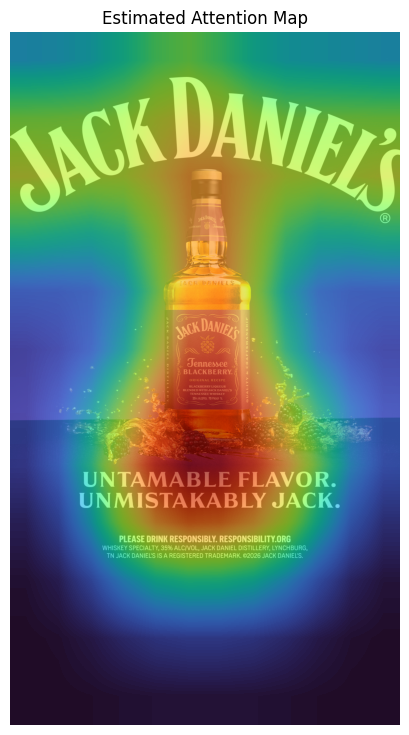

In [ ]:
# Visualización más fuerte del heatmap estimado

# Aumentar contraste del mapa
display_grid = np.power(attention_grid, 1.8)
display_grid = normalize_array(display_grid)

plt.figure(figsize=(7, 9))
plt.imshow(image)

plt.imshow(
    display_grid,
    cmap="turbo",
    alpha=0.68,
    extent=(0, image.size[0], image.size[1], 0),
    interpolation="bilinear"
)

plt.axis("off")
plt.title("Estimated Attention Map")
plt.show()

## 6. Overlay con zonas principales de atención

In [ ]:
def extract_attention_zones(cell_scores, top_n=5, min_distance=2):
    df = cell_scores.sort_values("attention_score", ascending=False).copy()
    selected = []

    for _, row in df.iterrows():
        gx, gy = int(row["gx"]), int(row["gy"])

        too_close = False
        for zone in selected:
            dx = gx - zone["gx"]
            dy = gy - zone["gy"]
            if math.sqrt(dx*dx + dy*dy) < min_distance:
                too_close = True
                break

        if not too_close:
            selected.append({
                "gx": gx,
                "gy": gy,
                "x0": int(row["x0"]),
                "y0": int(row["y0"]),
                "x1": int(row["x1"]),
                "y1": int(row["y1"]),
                "score": float(row["attention_score"]),
            })

        if len(selected) >= top_n:
            break

    return selected

zones = extract_attention_zones(cell_scores, top_n=5)
zones

[{'gx': 4,
  'gy': 9,
  'x0': 452,
  'y0': 1802,
  'x1': 565,
  'y1': 2002,
  'score': 1.0},
 {'gx': 7,
  'gy': 2,
  'x0': 791,
  'y0': 400,
  'x1': 904,
  'y1': 600,
  'score': 0.9501148110381199},
 {'gx': 5,
  'gy': 2,
  'x0': 565,
  'y0': 400,
  'x1': 678,
  'y1': 600,
  'score': 0.9383299779999631},
 {'gx': 4,
  'gy': 6,
  'x0': 452,
  'y0': 1201,
  'x1': 565,
  'y1': 1401,
  'score': 0.8852133766208243},
 {'gx': 3,
  'gy': 3,
  'x0': 339,
  'y0': 600,
  'x1': 452,
  'y1': 801,
  'score': 0.8655827389247008}]

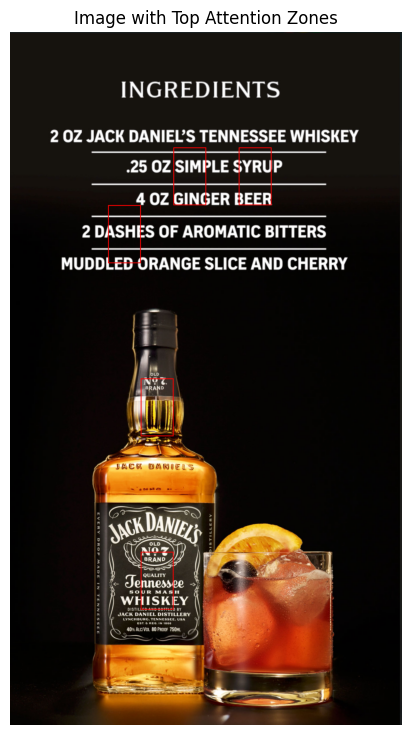

In [ ]:
img_with_zones = image.copy()
draw = ImageDraw.Draw(img_with_zones)

for i, zone in enumerate(zones):
    # Define the bounding box coordinates
    x0, y0, x1, y1 = zone["x0"], zone["y0"], zone["x1"], zone["y1"]
    bbox = [(x0, y0), (x1, y1)]

    # Draw a rectangle with a border
    draw.rectangle(bbox, outline="red", width=3)
    # Optionally, add a label for the zone score
    # draw.text((x0, y0 - 10), f'{zone["score"]:.2f}', fill="red", font=None)

show_image(img_with_zones, title="Image with Top Attention Zones")

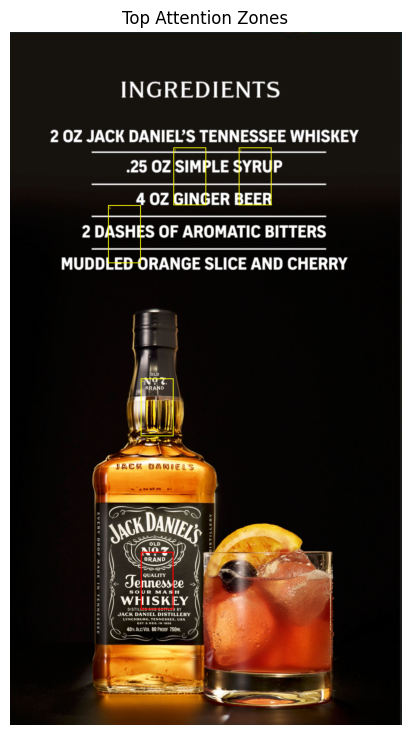

In [ ]:
overlay = image.copy()
draw = ImageDraw.Draw(overlay)

for i, zone in enumerate(zones, start=1):
    color = "red" if i == 1 else "yellow"
    width = 4 if i == 1 else 3
    draw.rectangle([zone["x0"], zone["y0"], zone["x1"], zone["y1"]], outline=color, width=width)
    draw.text((zone["x0"] + 4, zone["y0"] + 4), f"{i}", fill=color)

show_image(overlay, "Top Attention Zones")

## 7. Métricas derivadas

Focus Clarity

Mide qué tan concentrada está la atención en pocos focos.

Attention Dispersion

Mide qué tan distribuida está la atención sobre la pieza.

In [ ]:
def compute_attention_metrics(attention_grid):
    flat_raw = attention_grid.flatten()
    flat = flat_raw / (flat_raw.sum() + 1e-9)

    entropy = -np.sum(flat * np.log(flat + 1e-9))
    max_entropy = math.log(len(flat))
    attention_dispersion = clamp01(entropy / max_entropy)

    sorted_values = np.sort(flat_raw)[::-1]
    top1 = sorted_values[0]
    top3_mean = sorted_values[:3].mean()
    overall_mean = flat_raw.mean()

    focus_clarity = clamp01(
        0.50 * top1 +
        0.30 * top3_mean +
        0.20 * (1 - attention_dispersion)
    )

    visual_noise = clamp01(attention_dispersion * 0.65 + overall_mean * 0.35)

    return {
        "focus_clarity": focus_clarity,
        "attention_dispersion": attention_dispersion,
        "visual_noise": visual_noise,
        "primary_attention_score": float(top1),
        "top3_attention_mean": float(top3_mean),
    }

attention_metrics = compute_attention_metrics(attention_grid)
attention_metrics

{'focus_clarity': 0.80612231214566,
 'attention_dispersion': 0.9510123169621566,
 'visual_noise': 0.7817406494116044,
 'primary_attention_score': 1.0,
 'top3_attention_mean': 0.9877492517936378}

## 8. Lectura automática del diagnóstico

In [ ]:
def generate_attention_reading(metrics, zones):
    focus = metrics["focus_clarity"]
    dispersion = metrics["attention_dispersion"]
    noise = metrics["visual_noise"]

    if focus >= 0.70:
        focus_txt = "clear primary attention focus"
    elif focus >= 0.45:
        focus_txt = "moderate attention focus"
    else:
        focus_txt = "diffuse attention focus"

    if dispersion >= 0.70:
        dispersion_txt = "attention is highly dispersed across the asset"
    elif dispersion >= 0.45:
        dispersion_txt = "attention is moderately distributed"
    else:
        dispersion_txt = "attention is concentrated in a few areas"

    if noise >= 0.70:
        noise_txt = "high visual noise"
    elif noise >= 0.45:
        noise_txt = "moderate visual noise"
    else:
        noise_txt = "low visual noise"

    return (
        f"The asset shows {focus_txt}. "
        f"{dispersion_txt}. "
        f"The estimated map suggests {noise_txt}. "
        f"Primary attention zone score: {zones[0]['score']:.2f}."
    )

attention_reading = generate_attention_reading(attention_metrics, zones)
attention_reading

'The asset shows clear primary attention focus. attention is highly dispersed across the asset. The estimated map suggests high visual noise. Primary attention zone score: 1.00.'

## 9. Resumen para BrandRadar

In [ ]:
summary = pd.DataFrame([
{"Metric": "Focus Clarity", "Value": round(attention_metrics["focus_clarity"], 3)},
{"Metric": "Attention Dispersion", "Value": round(attention_metrics["attention_dispersion"], 3)},
{"Metric": "Visual Noise", "Value": round(attention_metrics["visual_noise"], 3)},
{"Metric": "Primary Attention Score", "Value": round(attention_metrics["primary_attention_score"], 3)},
{"Metric": "Top 3 Attention Mean", "Value": round(attention_metrics["top3_attention_mean"], 3)},
{"Metric": "Reading", "Value": attention_reading},
])

summary

,Metric,Value
0,Focus Clarity,0.806
1,Attention Dispersion,0.951
2,Visual Noise,0.782
3,Primary Attention Score,1.0
4,Top 3 Attention Mean,0.988
5,Reading,The asset shows clear primary attention focus....


## 10. Notas para integración futura

Este notebook puede convertirse en un servicio backend:

AttentionDiagnosticService

Inputs:

image_path
optional OCR text
optional layout regions

Outputs:

heatmap image
primary attention zones
focus_clarity
attention_dispersion
visual_noise
reading

Este módulo puede alimentar directamente:

Focus Clarity del radar
Visual Load
Attention Diagnostic view
Asset detail